# Weighted Data Curve Fitting Example: Temperature Dependence of Rate Constants (k)

#### ASU Online Physical Chemistry Laboratory




*Jeff Yarger, School of Molecular Sciences, Arizona State University.*

jyarger@proton.me


An Open-Source, Cross-Platform Resource for Nonlinear Least- Squares Curve Fitting,  *J. Chem. Educ.* 2018, 95, 2273-2278.

The temperature dependence of rate constants (k) in chemistry and biochemistry can often be modeled according to the Arrhenius equation:

\begin{equation}
k(T) =  A e^{-E_a/RT}
\end{equation}

where $A$ is the pre-exponential factor, $E_a$ is the activation energy, $R$ is the gas constant, and $T$ is the absolute temperature. (Accordingly, in this example $k(T)$ and $T$ are the dependent and independent variables, respectively.) To determine the parameters $A$ and $E_a$, the rate constant of a reaction of interest is hence recorded at several temperatures.

Typically, functional relationships are often transformed to linear equations. For example, in the Arrhenius formalism, the natural logarithm of $k(T)$ is linearly correlated with the reciprocal of the temperature, $1/T$:

\begin{equation}
\ln k(T) =  \ln A - E_a/RT
\end{equation}

Although this transformation holds the obvious attraction of affording straightforward data evaluation by graphical means or via conventional spreadsheet software (e.g., Excel or Google Sheets), students should be **dissuaded** from employing it.

The transformation affects the distribution of errors (or uncertainties) $\sigma_i$ for the individual data points $i$ and hence can yield quite different fit parameter values.

Let's give an example and use Colab (python) for data analysis, fitting and plotting.  Example experimental data measurements saved as an ascii (csv) file is provided on the CHM343 Github Data repository.

*   [Temp_Rate_Constant_kerr_Example_Data_CHM343.txt](https://raw.githubusercontent.com/CHM343/Data/main/Temp_Rate_Constant_kerr_Example_Data_CHM343.txt)

This data is three columns with temperature, rate constant and error (uncertainty) in the rate constant.  Using a fit of the Arrhenius equation, determine the activation energy ($E_a$) and the associated error in the calculated activation energy ($E_a$).  For completeness it is also useful to determine the pre-exponential factor $A$ and the associated uncertainty based on fitting to the Arrhenius equation.

In [1]:
# Python Libraries for display in Colab/Jupyter (Ipython)
from IPython import display
from IPython.display import Image

# Primary Python Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from functools import partial

# Additional Matplotlib components to make custom plots
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
import matplotlib.lines as lines
import matplotlib.ticker as ticker
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

In [2]:
# Define a function - Arrhenius equation - Arrhenius_f
def Arrhenius_f(T, A, Ea, R):
    """ The Arrhenius equation (k(T)) with pre-exponential factor (A), activation energy (Ea), gas constant (R), and absolute temperature (T). """
    return A * np.exp(-Ea / (R * T))

# Define a function - linearized Arrhenius equation - ln_Arrhenius_f
def ln_Arrhenius_f(T, A, Ea, R):
    """ The linearized Arrhenius equation (ln k(T)) with pre-exponential factor (A), activation energy (Ea), gas constant (R), and absolute temperature (T). """
    return np.log(A) - (Ea / (R * T))

In [3]:
# Load data from CHM343 Github using pandas read_csv function
T_k_Data = pd.read_csv('https://raw.githubusercontent.com/CHM343/Data/main/Temp_Rate_Constant_kerr_Example_Data_CHM343.txt', sep=',', header=0)

In [4]:
T_k_Data

,T (K),k (s-1),k_err
0,300.0,0.0238,0.00476
1,305.0,0.0334,0.00668
2,310.0,0.0400,0.00800
3,315.0,0.0691,0.01382
4,320.0,0.0820,0.01640
5,325.0,0.0965,0.01930
6,330.0,0.1479,0.02958
7,335.0,0.2031,0.04062
8,340.0,0.3093,0.06186
9,345.0,0.3700,0.07400


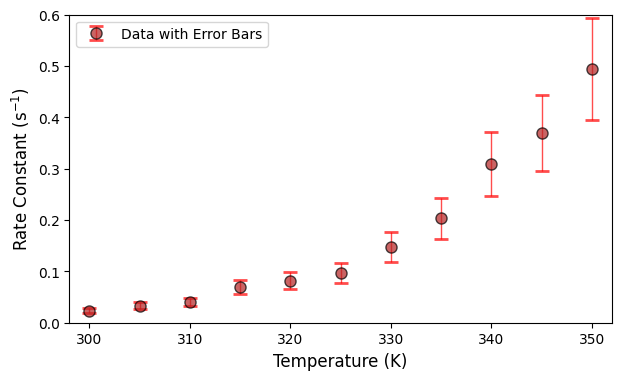

In [14]:
#plt.title('Example Plot of Data with Associated Error Bars', fontsize=16)
plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Rate Constant (s$^{-1}$)", fontsize=12)
plt.xlim(298,352)
plt.ylim(0,0.6)

plt.errorbar(T_k_Data['T (K)'], T_k_Data['k (s-1)'], yerr=T_k_Data['k_err'], fmt='o', color='firebrick', markersize =8, markeredgecolor='black', ecolor='red', capsize=5, capthick=2, elinewidth=1, alpha = 0.7, label='Data with Error Bars')

plt.gcf().set_size_inches(7, 4)

plt.legend()
plt.show()

Figure 1 - Linear scale plot of the data with associated error bars.

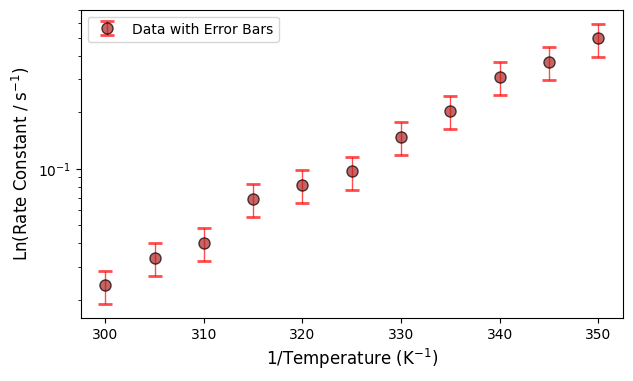

In [17]:
plt.xlabel("1/Temperature (K$^{-1}$)", fontsize=12)
plt.ylabel("Ln(Rate Constant / s$^{-1}$)", fontsize=12)
#plt.xlim(0.0028, 0.0033)
plt.yscale("log")

plt.errorbar(T_k_Data['T (K)'], T_k_Data['k (s-1)'], yerr=T_k_Data['k_err'], fmt='o', color='firebrick', markersize =8, markeredgecolor='black', ecolor='red', capsize=5, capthick=2, elinewidth=1, alpha = 0.7, label='Data with Error Bars')
# edgecolor='black',

plt.gcf().set_size_inches(7, 4)

plt.legend()
plt.show()

Figure 2 - Illustrate the issue when log plot is used and error bars are condensed.  Hence, go back to linear scale plot shown above for a non-linear weighted fitting of the data.

In [18]:
# Set Gas Constant
R=8.31446261815324

# Setup SciPy curve_fit without any consideration for data uncertainty (non-weighted fit) - Fix the value of R.
popt1, pcov = curve_fit(
    partial(Arrhenius_f, R=8.31446261815324),       # model function with R fixed at 8.314 J/Kmol
    xdata=T_k_Data['T (K)'],   # x data
    ydata=T_k_Data['k (s-1)'],   # y data
    p0=(10000000, 50000),      # initial value of the parameters A and Ea
    )

# y-values for non-weighted Arrhenius Equation fit
yfit1 = Arrhenius_f(T_k_Data['T (K)'], *popt1, R)

# Setup SciPy curve_fit without any consideration for data uncertainty (non-weighted fit) - Fix the value of R.
popt2, pcov2 = curve_fit(
    partial(Arrhenius_f, R=8.31446261815324),       # model function with R fixed at 8.314 J/Kmol
    xdata=T_k_Data['T (K)'],   # x data
    ydata=T_k_Data['k (s-1)'],   # y data
    p0=(10000000, 50000),      # initial value of the parameters A and Ea
    sigma=T_k_Data['k_err'],      # errors in y data
    absolute_sigma=True      # absolute errors - true
    )

# y-values for non-weighted Arrhenius Equation fit
yfit2 = Arrhenius_f(T_k_Data['T (K)'], *popt2, R)

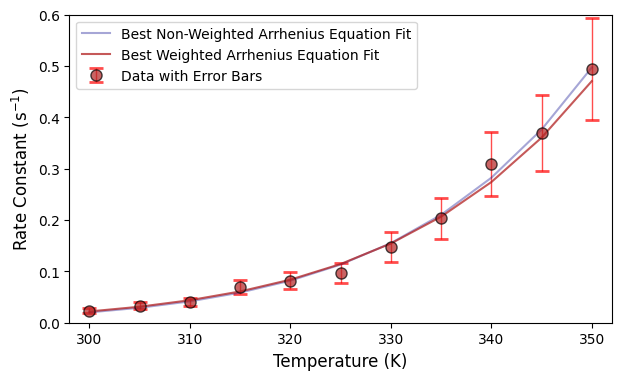

In [19]:
Arrhenius_Initial = Arrhenius_f(T_k_Data['T (K)'], 10000000, 50000, 8.31446261815324)

plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Rate Constant (s$^{-1}$)", fontsize=12)
plt.xlim(298,352)
plt.ylim(0,0.6)

plt.errorbar(T_k_Data['T (K)'], T_k_Data['k (s-1)'], yerr=T_k_Data['k_err'], fmt='o', color='firebrick', markersize =8, markeredgecolor='black', ecolor='red', capsize=5, capthick=2, elinewidth=1, alpha = 0.7, label='Data with Error Bars')
plt.plot(T_k_Data['T (K)'], yfit1, c='darkblue', alpha=0.35, label='Best Non-Weighted Arrhenius Equation Fit')
plt.plot(T_k_Data['T (K)'], yfit2, c='firebrick', alpha=0.75, label='Best Weighted Arrhenius Equation Fit')

plt.gcf().set_size_inches(7, 4)

plt.legend()
plt.show()

Figure 3 - Linear scale plot of the data with associated error bars.  A weighted (red line) and non-weighted (blue line) non-linear least squared best fit to the Arrhenius equation is shown in the plot.

popt1 and popt2 have the best fit parameters for the data.  Error analysis (uncertainties) can be done through the variance of the best fit data.